# 02 — CNN face detection & image-quality gates

Notebook độc lập với project code. Dùng **YuNet**, một CNN face detector nhẹ từ OpenCV Zoo, trên development subjects; không đọc holdout và chưa chọn verification threshold.


In [1]:
import os
import sys
import json
import random
import hashlib
import subprocess
from datetime import datetime, timezone
from pathlib import Path

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "scikit-learn>=1.5", "pandas>=2.2", "seaborn>=0.13",
    "opencv-python-headless>=4.10", "tqdm>=4.66",
])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter

SEED = 464
random.seed(SEED)
np.random.seed(SEED)

# A blank Colab runtime is the reference environment.  Nothing from src/ or
# scripts/ is needed.  All intermediate DS assets live under this runtime root.
RUNTIME_ROOT = Path("/content/facekyc_ds") if Path("/content").exists() else Path.cwd() / ".facekyc_ds"
DATA_ROOT = RUNTIME_ROOT / "data"
REPORT_ROOT = RUNTIME_ROOT / "reports"
ARTIFACT_ROOT = RUNTIME_ROOT / "artifacts"
for directory in (DATA_ROOT, REPORT_ROOT, ARTIFACT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

print("Runtime root:", RUNTIME_ROOT)
print("Python:", sys.version.split()[0])


Runtime root: /content/facekyc_ds
Python: 3.12.12


In [2]:
from sklearn.datasets import fetch_lfw_people

# This call downloads the official funneled LFW archive plus pair protocols.
_ = fetch_lfw_people(
    data_home=str(DATA_ROOT), color=True, resize=0.5,
    min_faces_per_person=0, download_if_missing=True,
)
LFW_HOME = DATA_ROOT / "lfw_home"
LFW_IMAGE_ROOT = LFW_HOME / "lfw_funneled"
assert LFW_IMAGE_ROOT.exists(), f"LFW extraction failed: {LFW_IMAGE_ROOT}"

def subject_bucket(subject):
    # Stable subject-level split: 80% train, 10% validation, 10% locked holdout.
    return int(hashlib.sha256(subject.encode("utf-8")).hexdigest()[:8], 16) % 10

def build_lfw_manifest():
    rows = []
    for path in sorted(LFW_IMAGE_ROOT.glob("*/*.jpg")):
        subject = path.parent.name
        bucket = subject_bucket(subject)
        split = "train" if bucket < 8 else ("validation" if bucket == 8 else "holdout")
        rows.append({"path": str(path), "subject": subject, "split": split})
    frame = pd.DataFrame(rows)
    assert len(frame) == 13233, f"Expected 13,233 LFW images, found {len(frame)}"
    assert frame.groupby("subject")["split"].nunique().max() == 1
    return frame

MANIFEST_PATH = DATA_ROOT / "lfw_subject_manifest.csv"
manifest = build_lfw_manifest()
manifest.to_csv(MANIFEST_PATH, index=False)
print("LFW images:", len(manifest), "subjects:", manifest.subject.nunique())


LFW images: 13233 subjects: 5749


In [3]:
import urllib.request
import cv2

model_path = DATA_ROOT / "face_detection_yunet_2023mar.onnx"
if not model_path.exists():
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx",
        model_path,
    )
detector = cv2.FaceDetectorYN.create(str(model_path), "", (320, 320), 0.75, 0.3, 5000)

def inspect_image(path):
    bgr = cv2.imread(str(path))
    assert bgr is not None, path
    height, width = bgr.shape[:2]
    detector.setInputSize((width, height))
    _, faces = detector.detect(bgr)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    brightness = float(gray.mean())
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    face_count = 0 if faces is None else len(faces)
    confidence = 0.0 if faces is None else float(faces[:, -1].max())
    largest = None if faces is None else faces[np.argmax(faces[:, 2] * faces[:, 3])]
    face_ratio = 0.0 if largest is None else float((largest[2] * largest[3]) / (width * height))
    return {"path": str(path), "detected": face_count > 0, "face_count": face_count,
            "confidence": confidence, "brightness": brightness,
            "sharpness": sharpness, "largest_face_ratio": face_ratio}, largest


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path,96,96,/content/facekyc_ds/data/lfw_home/lfw_funneled...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detected,96,1,True,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
face_count,96.0,NaN,NaN,NaN,1.145833,0.383314,1.0,1.0,1.0,1.0,3.0
confidence,96.0,NaN,NaN,NaN,0.931625,0.010045,0.893802,0.926484,0.933076,0.938096,0.948678
brightness,96.0,NaN,NaN,NaN,96.848861,27.650467,33.47176,77.885584,95.62124,114.583932,161.67496
sharpness,96.0,NaN,NaN,NaN,226.245714,190.518108,25.584495,87.813743,152.986105,280.213063,918.485385
largest_face_ratio,96.0,NaN,NaN,NaN,0.202083,0.026876,0.13674,0.186393,0.1993,0.214242,0.316201


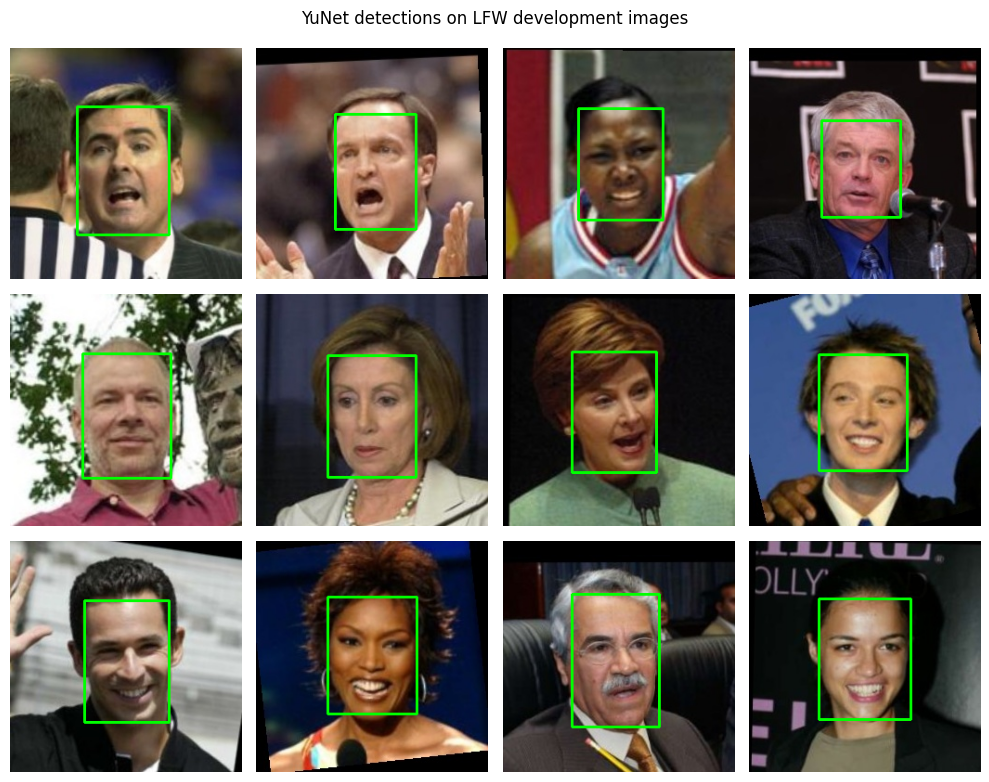

In [4]:
development = manifest.query("split == 'train'").sample(96, random_state=SEED)
rows, previews = [], []
for row in development.itertuples():
    result, face = inspect_image(row.path)
    rows.append(result)
    if face is not None and len(previews) < 12:
        bgr = cv2.imread(row.path)
        x, y, w, h = face[:4].astype(int)
        cv2.rectangle(bgr, (x, y), (x + w, y + h), (0, 255, 0), 2)
        previews.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
audit = pd.DataFrame(rows)
display(audit.describe(include="all").T)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for axis, image in zip(axes.ravel(), previews):
    axis.imshow(image); axis.axis("off")
plt.suptitle("YuNet detections on LFW development images")
plt.tight_layout(); plt.show()


In [5]:
accepted = audit[
    audit.detected & (audit.face_count == 1) & (audit.confidence >= 0.80)
    & audit.brightness.between(35, 220) & (audit.sharpness >= 20)
    & (audit.largest_face_ratio >= 0.08)
]
report = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "detector": "OpenCV YuNet 2023mar (CNN)",
    "dataset": "LFW train subjects only",
    "sample_images": int(len(audit)),
    "detection_rate": float(audit.detected.mean()),
    "single_face_rate": float((audit.face_count == 1).mean()),
    "quality_acceptance_rate": float(len(accepted) / len(audit)),
    "quality_gates": {"min_confidence": 0.80, "brightness": [35, 220], "min_sharpness": 20, "min_face_ratio": 0.08},
    "decision": "Use YuNet; recapture on no/multi-face or failed hard quality gate.",
    "holdout_accessed": False,
}
output = REPORT_ROOT / "02_detection_quality.json"
output.write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
report


{'created_at': '2026-08-27T15:11:18.500859+00:00',
 'detector': 'OpenCV YuNet 2023mar (CNN)',
 'dataset': 'LFW train subjects only',
 'sample_images': 96,
 'detection_rate': 1.0,
 'single_face_rate': 0.8645833333333334,
 'quality_acceptance_rate': 0.8541666666666666,
 'quality_gates': {'min_confidence': 0.8,
  'brightness': [35, 220],
  'min_sharpness': 20,
  'min_face_ratio': 0.08},
 'decision': 'Use YuNet; recapture on no/multi-face or failed hard quality gate.',
 'holdout_accessed': False}

## Kết luận sau khi chạy

Quality gates được tách khỏi similarity score: đầu vào lỗi phải yêu cầu chụp lại, không được diễn giải thành “khác người”. Threshold ở đây là operational starting point và cần hiệu chỉnh lại trên camera/ID-document đúng miền dữ liệu.
